# 00 — Mathematical Foundations for AI 🧮

Executable notebook for [`docs/curriculum/00-mathematical-foundations.md`](../docs/curriculum/00-mathematical-foundations.md).
Every topic in that syllabus — formulas, worked calculations, graphs, diagrams and tables —
is implemented below so you can **run the math, not just read it**.

| § | Topics |
|---|---|
| 1 · Linear algebra | dot/cosine · matmul shapes & broadcasting · linear layer · eigen→PCA · SVD/low-rank · positive-definite |
| 2 · Calculus | derivative · chain rule = backprop · gradient · partials · Hessian/saddle |
| 3 · Probability | Bayes · 5 distributions · expectation/variance · joint/marginal · likelihood/MLE · Monte Carlo |
| 4 · Statistics | estimator bias–variance · CI/p-values · correlation≠causation · MLE vs MAP · covariance |
| 5 · Optimization | convex vs non-convex · gradient descent family · learning rate · Lagrange · grid/random/Bayesian search |
| 6 · Information theory | entropy · cross-entropy loss · KL divergence · mutual information |

**How to use:** JupyterLab → *Run → Run All Cells* (`Shift+Enter` runs one cell).
Every `assert` is a teaching claim — if a cell errors, the math (or your edit) is wrong.
Companion tools: figures `python3 tools/make_math_figures.py` · number checker `python3 tools/calc_00_math.py`


In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
C = {"b": "#2563eb", "r": "#dc2626", "g": "#16a34a", "o": "#f59e0b",
     "p": "#7c3aed"}

print(f"numpy {np.__version__} · matplotlib ready · seed=0 set")


numpy 2.5.3 · matplotlib ready · seed=0 set


---
## §1 · Linear Algebra — the language of data

**Why AI runs on it:** every dataset is a matrix, every model is matrix operations,
GPUs exist to do fast matrix multiplication.

**🧮 Formula sheet — Linear Algebra Cheatsheet (Plain English)**

| What | Formula | Plain English |
|---|---|---|
| Dot product | `a·b = a₁b₁ + a₂b₂ + …` | Multiply matching entries of two vectors, then add them all up to get a single number. |
| Length (norm) | `‖a‖ = √(a₁² + a₂² + …)` | The straight-line distance from the origin to the vector's tip. |
| Cosine similarity | `cos θ = a·b / (‖a‖·‖b‖)` | Measures how aligned two vectors are. **1** = they point in the same direction; **0** = unrelated / perpendicular. |
| Matrix multiply | `C[i,j] = Σₖ A[i,k]·B[k,j]` | To find the item at row *i*, column *j* in the new matrix, take row *i* of matrix A and dot product it with column *j* of matrix B. |
| Shape rule | `(m×n) · (n×p) → (m×p)` | To multiply two matrices, the inner dimensions (**n**) must match. The result keeps the outer dimensions (**m × p**). |
| Linear layer | `Y = W·X + b` | The foundation of neural networks. **W** = learned weights, **b** = the bias, **X** = data with one column per sample. |


In [2]:
# --- The formula sheet as one picture: six rows → six panels ------
def matrix_grid(ax, M, x0, y0, w=0.5, h=0.5, fc="white", hi=(), hc="#fde68a",
                fs=8):
    """Draw matrix M as a grid of boxes; hi = coordinates to highlight."""
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.add_patch(plt.Rectangle((x0 + j * w, y0 - (i + 1) * h), w, h,
                                       fc=hc if (i, j) in hi else fc,
                                       ec="gray", lw=0.8))
            ax.text(x0 + (j + 0.5) * w, y0 - (i + 0.5) * h, f"{M[i, j]:g}",
                    ha="center", va="center", fontsize=fs)


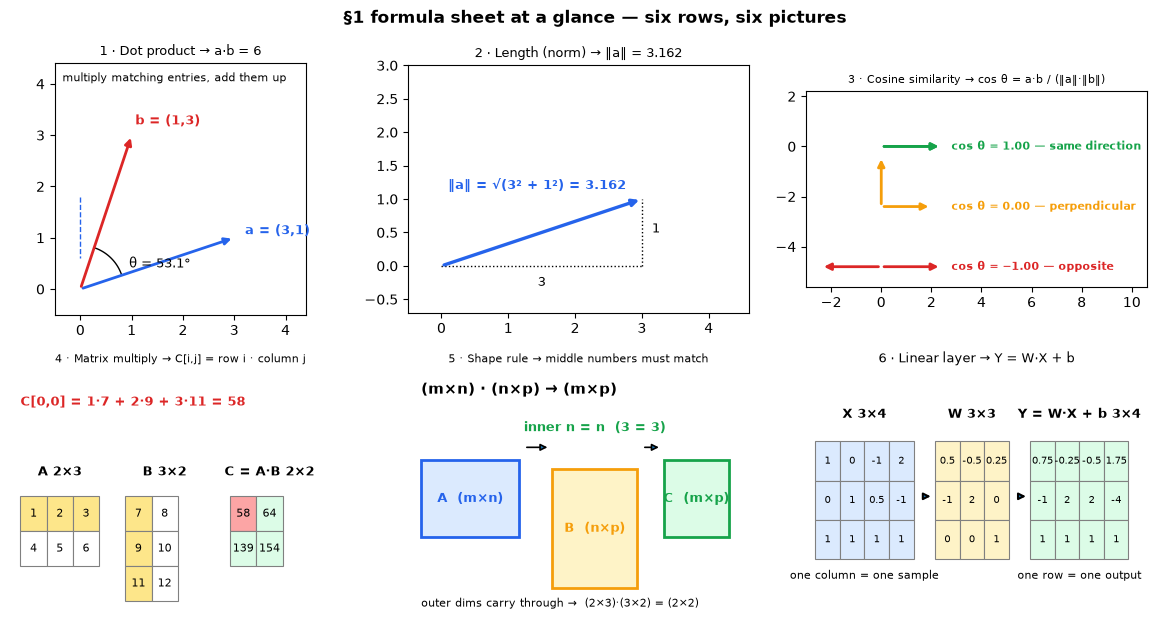

formula sheet → 6 panels ✓  a·b=6  ‖a‖=3.162  cos=0.60  θ=53.1°  C[0,0]=58  Y(3, 3)@X(3, 4)=(3, 4)


In [3]:
# --- Figure construction continues below ------
A = np.array([[1, 2, 3], [4, 5, 6]])                 # 2x3
B = np.array([[7, 8], [9, 10], [11, 12]])            # 3x2
Cmat = A @ B                                         # 2x2
a, b = np.array([3.0, 1.0]), np.array([1.0, 3.0])
dot = float(a @ b)
na, nb = float(np.linalg.norm(a)), float(np.linalg.norm(b))
cos = dot / (na * nb)
theta = float(np.degrees(np.arccos(cos)))
X = np.array([[1.0, 0.0, -1.0, 2.0],
              [0.0, 1.0, 0.5, -1.0],
              [1.0, 1.0, 1.0, 1.0]])                 # 3 features x 4 samples
W = np.array([[0.5, -0.5, 0.25],
              [-1.0, 2.0, 0.0],
              [0.0, 0.0, 1.0]])                      # 3 outputs x 3 features
assert Cmat.tolist() == [[58, 64], [139, 154]], Cmat
assert (dot, round(na, 3), round(cos, 2), round(theta, 2)) == (6.0, 3.162, 0.6, 53.13)
assert W.shape == (3, 3) and (W @ X).shape == (3, 4)
fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.4))
# 1 - dot product: multiply matching entries, then add
ax = axes[0, 0]
for v, c, lab in ((a, C["b"], "a = (3,1)"), (b, C["r"], "b = (1,3)")):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=c, lw=2))
    ax.text(*v * 1.07, lab, color=c, fontsize=9, weight="bold")
ax.plot(*np.vstack([a * 0, a * dot / na ** 2]), ls="--", color=C["b"], lw=1)
arc = np.linspace(np.arctan2(1, 3), np.arctan2(3, 1), 30)
ax.plot(0.85 * np.cos(arc), 0.85 * np.sin(arc), color="k", lw=1)
ax.text(0.95, 0.42, f"θ = {theta:.1f}°", fontsize=9)
ax.set_title(f"1 · Dot product → a·b = {dot:.0f}", fontsize=9.5)
ax.text(-0.35, 4.05, "multiply matching entries, add them up", fontsize=8)
ax.set_xlim(-0.5, 4.4); ax.set_ylim(-0.5, 4.4); ax.set_aspect("equal")

# 2 - norm: distance from the origin to the tip
ax = axes[0, 1]
ax.annotate("", xy=a, xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=C["b"], lw=2.4))
ax.plot([0, a[0]], [0, 0], "k:", lw=1)
ax.plot([a[0], a[0]], [0, a[1]], "k:", lw=1)
ax.text(1.5, -0.3, "3", ha="center", fontsize=9)
ax.text(3.15, 0.5, "1", fontsize=9)
ax.text(0.1, 1.15, f"‖a‖ = √(3² + 1²) = {na:.3f}", fontsize=9,
        weight="bold", color=C["b"])
ax.set_title(f"2 · Length (norm) → ‖a‖ = {na:.3f}", fontsize=9.5)
ax.set_xlim(-0.5, 4.6); ax.set_ylim(-0.7, 3.0); ax.set_aspect("equal")

# 3 - cosine similarity: 1, 0 and -1 side by side
ax = axes[0, 2]
for i, (u, v, lab, c) in enumerate((
        (np.array([2.4, 0.0]), np.array([2.4, 0.0]),
         "1.00 — same direction", C["g"]),
        (np.array([2.0, 0.0]), np.array([0.0, 2.0]),
         "0.00 — perpendicular", C["o"]),
        (np.array([2.4, 0.0]), np.array([-2.4, 0.0]),
         "−1.00 — opposite", C["r"]))):
    y = -i * 2.4
    for w in (u, v):
        ax.annotate("", xy=w + (0, y), xytext=(0, y),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=2))
    ax.text(2.8, y, f"cos θ = {lab}", fontsize=8, va="center",
            weight="bold", color=c)
ax.set_title("3 · Cosine similarity → cos θ = a·b / (‖a‖·‖b‖)",
             fontsize=8)
ax.set_xlim(-3.0, 10.6); ax.set_ylim(-5.6, 2.2); ax.set_aspect("equal")

# 4 - matrix multiply: row i of A dotted with column j of B
ax = axes[1, 0]
matrix_grid(ax, A, 0.0, 0.0, hi={(0, 0), (0, 1), (0, 2)})
matrix_grid(ax, B, 2.0, 0.0, hi={(0, 0), (1, 0), (2, 0)})
matrix_grid(ax, Cmat, 4.0, 0.0, fc="#dcfce7", hi={(0, 0)}, hc="#fca5a5")
ax.text(0.75, 0.3, "A 2×3", ha="center", fontsize=9, weight="bold")
ax.text(2.75, 0.3, "B 3×2", ha="center", fontsize=9, weight="bold")
ax.text(4.75, 0.3, "C = A·B 2×2", ha="center", fontsize=9, weight="bold")
ax.text(0.0, 1.3, "C[0,0] = 1·7 + 2·9 + 3·11 = 58", fontsize=9,
        weight="bold", color=C["r"])
ax.set_title("4 · Matrix multiply → C[i,j] = row i · column j", fontsize=8)
ax.set_xlim(-0.2, 6.3); ax.set_ylim(-1.8, 1.8); ax.axis("off")

# 5 - shape rule: inner dims must match, outer dims carry through
ax = axes[1, 1]
ax.add_patch(plt.Rectangle((0.2, 1.0), 1.5, 0.9, fc="#dbeafe", ec=C["b"], lw=2))
ax.text(0.95, 1.45, "A  (m×n)", ha="center", va="center", fontsize=9,
        weight="bold", color=C["b"])
ax.add_patch(plt.Rectangle((2.2, 0.4), 1.3, 1.4, fc="#fef3c7", ec=C["o"], lw=2))
ax.text(2.85, 1.1, "B  (n×p)", ha="center", va="center", fontsize=9,
        weight="bold", color=C["o"])
ax.add_patch(plt.Rectangle((3.9, 1.0), 1.0, 0.9, fc="#dcfce7", ec=C["g"], lw=2))
ax.text(4.4, 1.45, "C  (m×p)", ha="center", va="center", fontsize=9,
        weight="bold", color=C["g"])
ax.annotate("", xy=(2.17, 2.05), xytext=(1.77, 2.05),
            arrowprops=dict(arrowstyle="-|>", lw=1.2))
ax.annotate("", xy=(3.87, 2.05), xytext=(3.57, 2.05),
            arrowprops=dict(arrowstyle="-|>", lw=1.2))
ax.text(2.85, 2.24, "inner n = n  (3 = 3)", ha="center", fontsize=9,
        weight="bold", color=C["g"])
ax.text(0.2, 0.18, "outer dims carry through →  (2×3)·(3×2) = (2×2)", fontsize=8)
ax.text(0.2, 2.68, "(m×n) · (n×p) → (m×p)", fontsize=11, weight="bold")
ax.set_title("5 · Shape rule → middle numbers must match", fontsize=8)
ax.set_xlim(0.0, 5.2); ax.set_ylim(0.0, 2.95); ax.axis("off")

# 6 - linear layer: one column per sample, one row per output
ax = axes[1, 2]
matrix_grid(ax, X, 0.0, 0.0, w=0.8, fc="#dbeafe", fs=7.5)
matrix_grid(ax, W, 3.9, 0.0, w=0.8, fc="#fef3c7", fs=7.5)
matrix_grid(ax, W @ X, 7.0, 0.0, w=0.8, fc="#dcfce7", fs=7.5)
ax.text(1.6, 0.3, "X 3×4", ha="center", fontsize=9, weight="bold")
ax.text(5.1, 0.3, "W 3×3", ha="center", fontsize=9, weight="bold")
ax.text(8.6, 0.3, "Y = W·X + b 3×4", ha="center", fontsize=9, weight="bold")
ax.annotate("", xy=(3.85, -0.7), xytext=(3.45, -0.7),
            arrowprops=dict(arrowstyle="-|>", lw=1.5))
ax.annotate("", xy=(6.95, -0.7), xytext=(6.55, -0.7),
            arrowprops=dict(arrowstyle="-|>", lw=1.5))
ax.text(1.6, -1.75, "one column = one sample", ha="center", fontsize=8)
ax.text(8.6, -1.75, "one row = one output", ha="center", fontsize=8)
ax.set_title("6 · Linear layer → Y = W·X + b", fontsize=9.5)
ax.set_xlim(-0.3, 10.8); ax.set_ylim(-2.3, 0.9); ax.axis("off")
fig.suptitle("§1 formula sheet at a glance — six rows, six pictures",
             fontsize=12, weight="bold")
fig.tight_layout()
plt.show()
print(f"formula sheet → 6 panels ✓  a·b={dot:.0f}  ‖a‖={na:.3f}  "
      f"cos={cos:.2f}  θ={theta:.1f}°  C[0,0]={Cmat[0,0]}  "
      f"Y{W.shape}@X{X.shape}={(W @ X).shape}")


In [4]:
# --- Matrix multiply BY HAND: every cell, expanded -------------------------
A = np.array([[1, 2, 3],
              [4, 5, 6]])              # 2×3
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])               # 3×2

assert A.shape[1] == B.shape[0], "inner dimensions must match (3 = 3)"
print(f"shapes: {A.shape} · {B.shape} → ({A.shape[0]}×{B.shape[1]})  ✓ middle 3=3\n")

Cmat = np.zeros((2, 2), dtype=int)
for i in range(2):
    for j in range(2):
        terms = " + ".join(f"{A[i,k]}·{B[k,j]}" for k in range(3))
        Cmat[i, j] = (A[i] * B[:, j]).sum()
        print(f"C[{i},{j}] = {terms:>24} = {Cmat[i,j]:>4}")

assert Cmat.tolist() == [[58, 64], [139, 154]], Cmat
print(f"\nA · B = {Cmat.tolist()}   ✓ matches the doc")

# --- Broadcasting & batches: one matmul scores a whole mini-batch ---------
X = np.array([[1.0, 0.0, -1.0, 2.0],     # 3 features × 4 samples
              [0.0, 1.0,  0.5, -1.0],
              [1.0, 1.0,  1.0,  1.0]])
W = np.array([[0.5, -0.5, 0.25],
              [-1.0, 2.0, 0.0],
              [0.0, 0.0, 1.0]])          # 3 outputs × 3 features
Y = W @ X                                # (3×3)·(3×4) → 3×4
assert Y.shape == (3, 4)
print(f"\nlinear layer: W{W.shape} @ X{X.shape} → Y{Y.shape}")
print(f"column 1 (one sample's scores): {np.round(Y[:, 0], 3).tolist()}")
print("→ N samples = N columns: that is why deep learning is one big matmul")


shapes: (2, 3) · (3, 2) → (2×2)  ✓ middle 3=3

C[0,0] =         1·7 + 2·9 + 3·11 =   58
C[0,1] =        1·8 + 2·10 + 3·12 =   64
C[1,0] =         4·7 + 5·9 + 6·11 =  139
C[1,1] =        4·8 + 5·10 + 6·12 =  154

A · B = [[58, 64], [139, 154]]   ✓ matches the doc

linear layer: W(3, 3) @ X(3, 4) → Y(3, 4)
column 1 (one sample's scores): [0.75, -1.0, 1.0]
→ N samples = N columns: that is why deep learning is one big matmul


**Worked calculation — cosine similarity** of two "embeddings" `a=(3,1)`, `b=(1,3)`:

| step | formula | numbers | result |
|---|---|---|---|
| 1 · dot | `Σ aᵢ·bᵢ` | `3·1 + 1·3` | 6 |
| 2 · norms | `√(a₁²+a₂²)` | `√10` each | 3.162 |
| 3 · cosine | `a·b / (‖a‖·‖b‖)` | `6 / 10` | **0.60** |
| 4 · angle | `arccos(0.60)` | — | **53.13°** |


a·b = 6  ‖a‖ = 3.162  cos θ = 0.60  θ = 53.13°   ✓
cosine(a,a) = 1.000 (identical → 1)   cosine(a,-a) = -1.000 (opposite → −1)


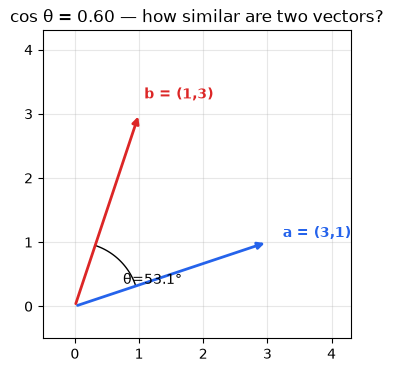

In [5]:
def cosine(a, b):
    """The similarity used by embeddings, attention, and your vector DB."""
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

a, b = np.array([3.0, 1.0]), np.array([1.0, 3.0])
cos_ab, theta = cosine(a, b), math.degrees(math.acos(cosine(a, b)))
assert abs(cos_ab - 0.6) < 1e-12 and abs(theta - 53.13) < 0.01
print(f"a·b = {a@b:.0f}  ‖a‖ = {np.linalg.norm(a):.3f}  "
      f"cos θ = {cos_ab:.2f}  θ = {theta:.2f}°   ✓")
print(f"cosine(a,a) = {cosine(a,a):.3f} (identical → 1)   "
      f"cosine(a,-a) = {cosine(a,-a):.3f} (opposite → −1)")

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.annotate("", xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=C["b"], lw=2))
ax.annotate("", xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=C["r"], lw=2))
ax.text(*a * 1.08, "a = (3,1)", color=C["b"], weight="bold")
ax.text(*b * 1.08, "b = (1,3)", color=C["r"], weight="bold")
arc = np.linspace(math.atan2(1, 3), math.atan2(3, 1), 30)
ax.plot(1.0 * np.cos(arc), 1.0 * np.sin(arc), "k-", lw=1)
ax.text(0.75, 0.35, f"θ={theta:.1f}°")
ax.set_xlim(-0.5, 4.3); ax.set_ylim(-0.5, 4.3)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_title(f"cos θ = {cos_ab:.2f} — how similar are two vectors?")
plt.show()


**Eigen-decomposition → PCA:** the eigenvectors of the covariance matrix are the
principal directions of your data; eigenvalues are how much variance lives along each.


**🔢 Worked calculation — eigen-decomposition → PCA, by hand on the simplest case**

Take the symmetric `C = [[2,1],[1,2]]` (a 2×2 covariance matrix). No library needed:

| step | formula | numbers | result |
|---|---|---|---|
| 1 · characteristic equation | `det(C − λI) = 0` ⇒ `λ² − trace·λ + det = 0` | `λ² − 4λ + 3 = 0` | — |
| 2 · eigenvalues | `λ = (trace ± √(trace² − 4·det)) / 2` | `(4 ± √4)/2` | **λ₁ = 3, λ₂ = 1** |
| 3 · eigenvector for λ₁ | `(C − 3I)·v = 0` | `[[−1,1],[1,−1]]·v = 0` | **v₁ = (1,1)/√2** |
| 4 · eigenvector for λ₂ | `(C − 1I)·v = 0` | `[[1,1],[1,1]]·v = 0` | **v₂ = (1,−1)/√2** |
| 5 · PCA variance share | `λᵢ / Σλ` | `3/4` vs `1/4` | **PC1 = 75%** |
| 6 · project x = (2,3) | `x·v₁` | `(2+3)/√2` | **3.536** |


C = [[2.0, 1.0], [1.0, 2.0]]   trace = 4   det = 3
λ² − 4λ + 3 = 0 → λ = (4 ± √4)/2 = 3.000, 1.000
v1 = [0.707, 0.707] (λ=3) → C·v1 = [2.121, 2.121] = 3·v1 ✓
v2 = [0.707, -0.707] (λ=1) → C·v2 = [0.707, -0.707] = 1·v2 ✓
v1·v2 = 0 ✓ orthogonal   |   λ1+λ2 = 4 = trace, λ1·λ2 = 3 = det
numpy eigh() agrees: λ = [3.0, 1.0] ✓ (the sign of each eigenvector is arbitrary)
PC1 keeps 75% of the variance, PC2 keeps the remaining 25%
project x = [2.0, 3.0] onto PC1: x·v1 = (2+3)/√2 = 3.536
→ PCA on 10 000 dimensions is the same two steps: covariance → top eigenvectors


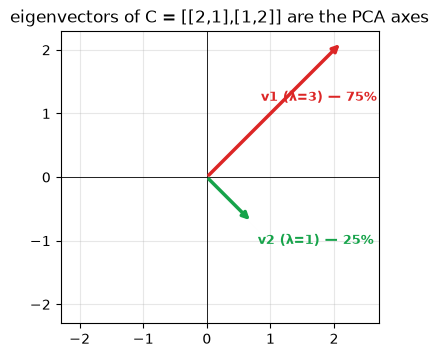

In [6]:
# --- The same six steps in code: hand formulas first, eigh() to confirm -----
C2 = np.array([[2.0, 1.0], [1.0, 2.0]])          # symmetric 2×2 "covariance"
trace2, det2 = float(np.trace(C2)), float(np.linalg.det(C2))
disc = math.sqrt(trace2 ** 2 - 4 * det2)         # √(trace² − 4·det)
lam1, lam2 = (trace2 + disc) / 2, (trace2 - disc) / 2
print(f"C = {C2.tolist()}   trace = {trace2:.0f}   det = {det2:.0f}")
print(f"λ² − {trace2:.0f}λ + {det2:.0f} = 0 → λ = ({trace2:.0f} ± √{disc ** 2:.0f})/2 "
      f"= {lam1:.3f}, {lam2:.3f}")
# det() is LU-based → 2.9999999999999996, so the eigenvalues need a tolerance
assert abs(lam1 - 3.0) < 1e-12 and abs(lam2 - 1.0) < 1e-12, (lam1, lam2)

v1 = np.array([1.0, 1.0]) / np.sqrt(2)            # (C − 3I)v = 0
v2 = np.array([1.0, -1.0]) / np.sqrt(2)           # (C − 1I)v = 0
for lam, v in ((lam1, v1), (lam2, v2)):
    assert np.allclose(C2 @ v, lam * v, atol=1e-15), (lam, v)
assert abs(float(v1 @ v2)) < 1e-15                            # orthogonal
assert abs(abs(float(np.linalg.det(np.c_[v1, v2]))) - 1) < 1e-12   # orthonormal
print(f"v1 = {np.round(v1, 3).tolist()} (λ=3) → C·v1 = "
      f"{np.round(C2 @ v1, 3).tolist()} = 3·v1 ✓")
print(f"v2 = {np.round(v2, 3).tolist()} (λ=1) → C·v2 = "
      f"{np.round(C2 @ v2, 3).tolist()} = 1·v2 ✓")
print(f"v1·v2 = {v1 @ v2:.0f} ✓ orthogonal   |   λ1+λ2 = {lam1 + lam2:.0f} = trace, "
      f"λ1·λ2 = {lam1 * lam2:.0f} = det")

evals2, evecs2 = np.linalg.eigh(C2)               # ascending λ, columns match
evals2, evecs2 = evals2[::-1], evecs2[:, ::-1]    # → descending, like the hand calc
assert np.allclose(evals2, [lam1, lam2])
assert all(abs(abs(float(evecs2[:, i] @ v)) - 1) < 1e-12
           for i, v in enumerate((v1, v2)))
print(f"numpy eigh() agrees: λ = {np.round(evals2, 3).tolist()} ✓ "
      f"(the sign of each eigenvector is arbitrary)")

# --- PCA = keep the top eigenvalue's direction, drop the rest ---------------
frac = np.array([lam1, lam2]) / (lam1 + lam2)
x_pt = np.array([2.0, 3.0])                       # one data point
proj = float(x_pt @ v1)                           # its PC1 score
assert np.allclose(frac, [0.75, 0.25]) and abs(proj - 3.5355) < 1e-3
print(f"PC1 keeps {frac[0]:.0%} of the variance, PC2 keeps the remaining {frac[1]:.0%}")
print(f"project x = {x_pt.tolist()} onto PC1: x·v1 = (2+3)/√2 = {proj:.3f}")
print("→ PCA on 10 000 dimensions is the same two steps: covariance → top eigenvectors")

fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.annotate("", xy=lam1 * v1, xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=C["r"], lw=2.5))
ax.annotate("", xy=lam2 * v2, xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=C["g"], lw=2.5))
ax.text(0.85, 1.2, "v1 (λ=3) — 75%", color=C["r"], weight="bold", fontsize=9)
ax.text(0.8, -1.05, "v2 (λ=1) — 25%", color=C["g"], weight="bold", fontsize=9)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(0, color="k", lw=0.6)
ax.set_xlim(-2.3, 2.7); ax.set_ylim(-2.3, 2.3)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_title("eigenvectors of C = [[2,1],[1,2]] are the PCA axes")
plt.show()


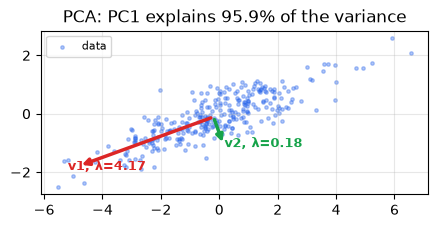

eigenvalues            = [4.166, 0.178]
variance explained     = [0.959, 0.041]
both λ > 0 → covariance is POSITIVE DEFINITE ✓ (a Gaussians/loss-surface property)


In [7]:
# Correlated 2-D data → covariance → eigen → PCA axes
rng = np.random.default_rng(1)
z = rng.normal(size=300)
data = np.c_[2.0 * z + 0.4 * rng.normal(size=300),
             0.8 * z + 0.4 * rng.normal(size=300)]        # strongly correlated
cov = np.cov(data.T)                                      # 2×2 covariance matrix
evals, evecs = np.linalg.eigh(cov)                        # symmetric → eigh
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]          # sort eigenpairs desc

mu = data.mean(0)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(*data.T, s=6, alpha=0.35, color=C["b"], label="data")
for i, (val, vec) in enumerate(zip(evals, evecs.T)):
    color = C["r"] if i == 0 else C["g"]
    ax.annotate("", xy=mu + 2.4 * np.sqrt(val) * vec, xytext=mu,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5))
    ax.text(*(mu + 2.6 * np.sqrt(val) * vec), f"v{i+1}, λ={val:.2f}",
            color=color, weight="bold", fontsize=9)
explained = evals / evals.sum()
ax.set_title(f"PCA: PC1 explains {explained[0]:.1%} of the variance")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()
print(f"eigenvalues            = {np.round(evals, 3).tolist()}")
print(f"variance explained     = {np.round(explained, 3).tolist()}")
print(f"both λ > 0 → covariance is POSITIVE DEFINITE ✓ (a Gaussians/loss-surface property)")
assert evals.min() > 0 and explained[0] > 0.85


**SVD / low-rank:** store `k·(m+n)` numbers instead of `m·n` — compression,
embedding geometry, and parameter-efficient fine-tuning are all this picture.


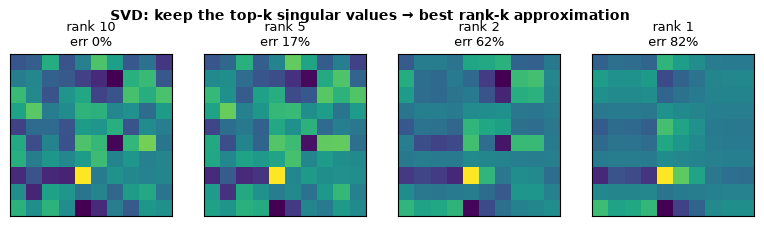

relative error by rank: ['0.00', '0.17', '0.62', '0.82']
→ truncating too hard costs accuracy; keeping a few directions captures most of it ✓


In [8]:
A = rng.normal(size=(10, 10)) @ rng.normal(size=(10, 10))   # any 10×10 matrix
U, s, Vt = np.linalg.svd(A, full_matrices=False)
fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.6))
errors = []
for ax, k in zip(axes, (10, 5, 2, 1)):
    Ak = (U[:, :k] * s[:k]) @ Vt[:k]                          # rank-k truncation
    err = np.linalg.norm(A - Ak) / np.linalg.norm(A)
    errors.append(err)
    ax.imshow(Ak, cmap="viridis"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"rank {k}\nerr {err:.0%}", fontsize=9)
fig.suptitle("SVD: keep the top-k singular values → best rank-k approximation",
             fontsize=10, weight="bold")
plt.show()
print(f"relative error by rank: {[f'{e:.2f}' for e in errors]}")
# k=10,5,2,1 → error must GROW monotonically as the rank budget shrinks
assert errors[0] < 1e-9 and errors == sorted(errors), "error grows as k shrinks"
assert errors[-1] > 0.4                                          # rank-1 loses a lot
print("→ truncating too hard costs accuracy; keeping a few directions captures most of it ✓")


---
## §2 · Calculus & Gradients — how models learn

**🧮 Formula sheet**

| Rule | Formula | Says |
|---|---|---|
| Power rule | `d/dx xⁿ = n·xⁿ⁻¹` | bring the exponent down, drop one |
| Exponential | `d/dx eˣ = eˣ` | its slope equals its value |
| Chain rule | `dL/dx = (dL/dg)·(dg/dx)` | multiply the local slopes along the way |
| Partial | `∂f/∂xᵢ` | slope along ONE axis, others frozen |
| Gradient | `∇f = (∂f/∂x₁, …, ∂f/∂xₙ)` | full vector of slopes = steepest climb |
| Learning step | `w ← w − η·∇L` | subtract gradient × learning rate |


f(x)=x³−x → f′(x)=3x²−1
  analytic      f′(1.3) = 4.0700
  limit (h→0)   [0.897004 − 0.897000] / 1e-06 = 4.0700  ✓


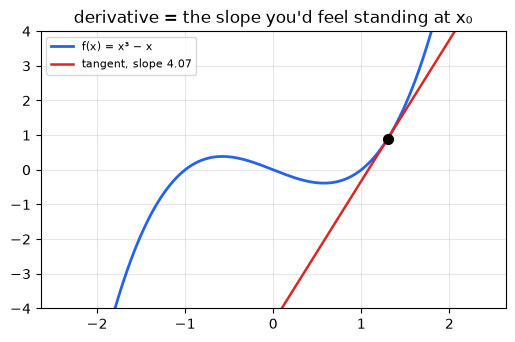


rules table:
  d/dx x⁵         formula=   14.2805  numeric=   14.2805  ✓
  d/dx eˣ         formula=    3.6693  numeric=    3.6693  ✓
  d/dx 3x²+2x     formula=    9.8000  numeric=    9.8000  ✓


In [9]:
# --- Derivative = slope of the tangent = limit of the secant --------------
f  = lambda x: x ** 3 - x
df = lambda x: 3 * x ** 2 - 1                 # analytic (power rule)

x0, h = 1.3, 1e-6
secant = (f(x0 + h) - f(x0)) / h              # limit definition
assert abs(secant - df(x0)) < 1e-3, "limit definition must match the power rule"
print(f"f(x)=x³−x → f′(x)=3x²−1")
print(f"  analytic      f′({x0}) = {df(x0):.4f}")
print(f"  limit (h→0)   [{f(x0+h):.6f} − {f(x0):.6f}] / {h} = {secant:.4f}  ✓")

x = np.linspace(-2.4, 2.4, 400)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(x, f(x), color=C["b"], lw=2, label="f(x) = x³ − x")
ax.plot(x, f(x0) + df(x0) * (x - x0), color=C["r"], lw=1.8,
        label=f"tangent, slope {df(x0):.2f}")
ax.plot(x0, f(x0), "ko", ms=7)
ax.set_ylim(-4, 4); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("derivative = the slope you'd feel standing at x₀")
plt.show()

# --- Derivative rules mini-check (power / exp) against finite differences --
print("\nrules table:")
for name, g, dg in (
        ("x⁵",        lambda t: t**5,      lambda t: 5*t**4),
        ("eˣ",        np.exp,              np.exp),
        ("3x²+2x",    lambda t: 3*t**2+2*t,lambda t: 6*t+2)):
    approx = (g(x0 + h) - g(x0 - h)) / (2 * h)     # central difference
    ok = abs(approx - dg(x0)) < 1e-3
    print(f"  d/dx {name:<10} formula={dg(x0):>10.4f}  numeric={approx:>10.4f}  {'✓' if ok else '✗'}")
    assert ok


**Worked — chain rule = backpropagation.** For `L = (2x+1)³` at `x = 1`:

| step | what | calculation | value |
|---|---|---|---|
| 1 | inner value | `g = 2·1 + 1` | 3 |
| 2 | inner slope | `dg/dx` | 2 |
| 3 | outer slope | `dL/dg = 3g² = 3·3²` | 27 |
| 4 | multiply | `27 × 2` | **54** |

Neural nets are just this picture repeated thousands of times, systematically.


x=1.0 → g=3 → ∂L/∂g=3·3²=27 → dL/dx = 27 × 2 = 54
finite-difference check: 54.00   ✓ 54


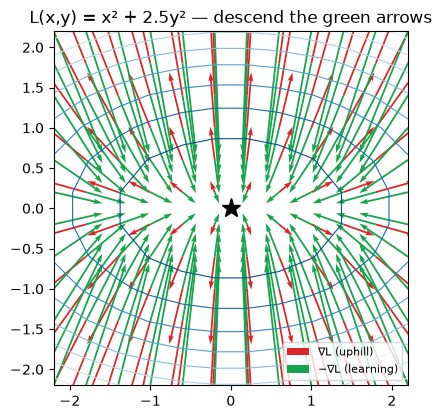

∇L(1,1) = (∂L/∂x₁, ∂L/∂x₂) = (2, 4)   ✓ (numeric: [2.0, 4.0])

Hessian eigenvalues classify critical points:
  x²+y²  (min)     λ = [2.0, 2.0] → minimum
  x²−y²  (saddle)  λ = [-2.0, 2.0] → SADDLE
  −x²−y² (max)     λ = [-2.0, -2.0] → maximum
→ saddles have vanishing gradients but no minimum: they stall naive optimizers ✓


In [10]:
# Chain rule, computed piece by piece + verified by finite differences
L   = lambda g: g ** 3
g_of = lambda x: 2 * x + 1

x0 = 1.0
g   = g_of(x0)               # inner value            = 3
dg  = 2.0                    # ∂g/∂x
dL  = 3 * g ** 2             # ∂L/∂g = 27
chain = dL * dg              # 54
fd = (L(g_of(x0 + 1e-6)) - L(g_of(x0))) / 1e-6

print(f"x={x0} → g={g:.0f} → ∂L/∂g=3·{g:.0f}²={dL:.0f} → dL/dx = {dL:.0f} × {dg:.0f} = {chain:.0f}")
print(f"finite-difference check: {fd:.2f}   ✓ 54")
assert chain == 54 and abs(fd - chain) < 1e-3

# --- Gradient field: ∇L points uphill, learning goes the other way --------
gx, gy = np.meshgrid(np.linspace(-2.2, 2.2, 12), np.linspace(-2.2, 2.2, 12))
L2 = gx ** 2 + 2.5 * gy ** 2
fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.contour(gx, gy, L2, levels=10, cmap="Blues_r", linewidths=0.8)
ax.quiver(gx, gy, 2 * gx, 5 * gy, color=C["r"], scale=32, width=0.005,
          label="∇L (uphill)")
ax.quiver(gx, gy, -2 * gx, -5 * gy, color=C["g"], scale=32, width=0.005,
          label="−∇L (learning)")
ax.plot(0, 0, "k*", ms=14)
ax.set_aspect("equal"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("L(x,y) = x² + 2.5y² — descend the green arrows")
plt.show()

# --- Partials & gradient at a point ---------------------------------------
x1v, x2v = 1.0, 1.0
L3 = lambda a, b: a ** 2 + 2 * b ** 2
grad = np.array([2 * x1v, 4 * x2v])                 # (2, 4)
fd_g = np.array([(L3(x1v + 1e-6, x2v) - L3(x1v - 1e-6, x2v)) / 2e-6,
                 (L3(x1v, x2v + 1e-6) - L3(x1v, x2v - 1e-6)) / 2e-6])
assert np.allclose(grad, fd_g, atol=1e-4)
print(f"∇L(1,1) = (∂L/∂x₁, ∂L/∂x₂) = ({grad[0]:.0f}, {grad[1]:.0f})   ✓ "
      f"(numeric: {np.round(fd_g, 3).tolist()})")

# --- Hessian: minimum vs saddle -------------------------------------------
from numpy.linalg import eigvalsh
cases = {"x²+y²  (min)":    np.array([[2, 0], [0, 2]]),
         "x²−y²  (saddle)": np.array([[2, 0], [0, -2]]),
         "−x²−y² (max)":    np.array([[-2, 0], [0, -2]])}
print("\nHessian eigenvalues classify critical points:")
for name, Hmat in cases.items():
    ev = eigvalsh(Hmat)
    kind = "minimum" if (ev > 0).all() else ("maximum" if (ev < 0).all() else "SADDLE")
    print(f"  {name:<16} λ = {ev.tolist()} → {kind}")
    assert (ev > 0).all() or (ev < 0).all() or ev.prod() < 0
print("→ saddles have vanishing gradients but no minimum: they stall naive optimizers ✓")


---
## §3 · Probability — reasoning under uncertainty

**🧮 Formula sheet**

| Rule | Formula | Plain English |
|---|---|---|
| Conditional | `P(A\|B) = P(A∩B) / P(B)` | A's share once you restrict to B |
| Bayes | `P(H\|D) = P(D\|H)·P(H) / P(D)` | update belief after seeing evidence |
| Total probability | `P(D) = Σₕ P(D\|Hₕ)·P(Hₕ)` | every way the evidence can happen |
| Independence | `P(A∩B) = P(A)·P(B)` | only if knowing A says nothing about B |
| Expectation | `E[X] = Σ x·p(x)` | probability-weighted average |
| Variance | `Var = E[X²] − (E[X])²` | average squared spread around the mean |


group             size    P(+|group)    expected +
sick                10          0.90           9.0
healthy            990          0.05          49.5
all positives                                  58.5

P(sick|+) = 0.009 / 0.0585 = 0.1538 → 15.4%
⚠️  P(+|sick) = 90% but P(sick|+) = 15.4% — conditioning flipped it!


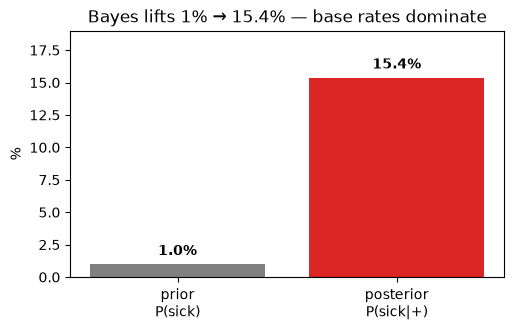

In [11]:
# --- Bayes' rule on the medical-test paradox (exercise #3) ----------------
prev, sens, fpr = 0.01, 0.90, 0.05            # 1% sick, 90% sensitive, 5% false alarm
joint_pos = prev * sens                        # P(sick AND +)
joint_fp  = (1 - prev) * fpr                   # P(healthy AND +)
p_pos     = joint_pos + joint_fp               # P(+)
post      = joint_pos / p_pos                  # P(sick | +)

print(f"{'group':<12}{'size':>10}{'P(+|group)':>14}{'expected +':>14}")
print(f"{'sick':<12}{prev*1000:>10.0f}{sens:>14.2f}{prev*1000*sens:>14.1f}")
print(f"{'healthy':<12}{(1-prev)*1000:>10.0f}{fpr:>14.2f}{(1-prev)*1000*fpr:>14.1f}")
print(f"{'all positives':<12}{'':>10}{'':>14}{p_pos*1000:>14.1f}\n")
print(f"P(sick|+) = {joint_pos:.3f} / {p_pos:.4f} = {post:.4f} → {post:.1%}")
print(f"⚠️  P(+|sick) = {sens:.0%} but P(sick|+) = {post:.1%} — conditioning flipped it!")
assert abs(post - 0.153846) < 1e-5, "posterior must be 15.4%, not 90%"

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.bar(["prior\nP(sick)", "posterior\nP(sick|+)"], [prev * 100, post * 100],
       color=["gray", C["r"]])
for i, v in enumerate([prev * 100, post * 100]):
    ax.text(i, v + 0.7, f"{v:.1f}%", ha="center", weight="bold")
ax.set_ylabel("%"); ax.set_ylim(0, 19)
ax.set_title("Bayes lifts 1% → 15.4% — base rates dominate")
plt.show()


**📋 The five distributions you must know** — shape, E[X]/Var quick table, and where AI uses them.


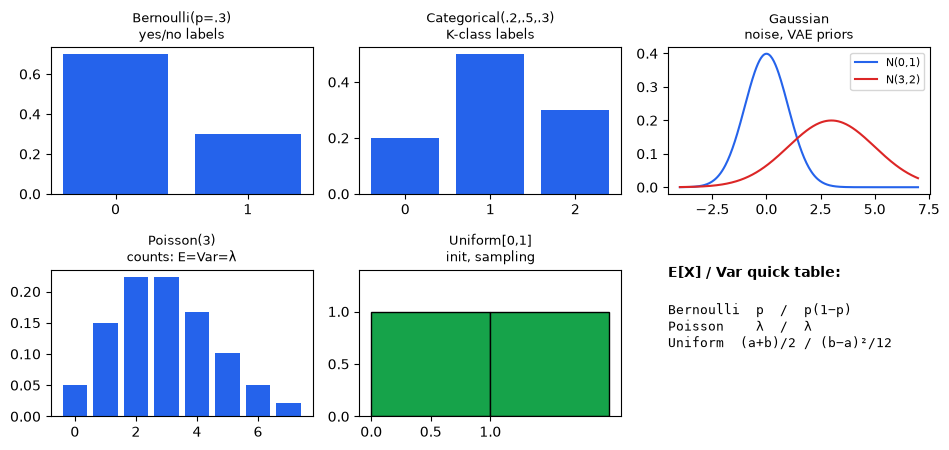

Poisson(3): k≤7 shows 0.988 of the mass; full series sums to 1.000000000 ✓  ·  identity E=Var=λ=3 ✓


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(9.6, 4.6))
ax = axes[0, 0]
ax.bar([0, 1], [.7, .3], color=C["b"]); ax.set_xticks([0, 1])
ax.set_title("Bernoulli(p=.3)\nyes/no labels", fontsize=9)
ax = axes[0, 1]
ax.bar([0, 1, 2], [.2, .5, .3], color=C["b"]); ax.set_xticks([0, 1, 2])
ax.set_title("Categorical(.2,.5,.3)\nK-class labels", fontsize=9)
ax = axes[0, 2]
xs = np.linspace(-4, 7, 300)
ax.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), color=C["b"], label="N(0,1)")
ax.plot(xs, np.exp(-(xs-3)**2/8)/np.sqrt(8*np.pi), color=C["r"], label="N(3,2)")
ax.legend(fontsize=8); ax.set_title("Gaussian\nnoise, VAE priors", fontsize=9)
ax = axes[1, 0]
ks = np.arange(8); lam = 3.0
pmf = np.exp(-lam) * lam**ks / np.array([math.factorial(int(k)) for k in ks])
ax.bar(ks, pmf, color=C["b"]); ax.set_title("Poisson(3)\ncounts: E=Var=λ", fontsize=9)
ax = axes[1, 1]
ax.bar([0, 1], [1, 1], color=C["g"], width=1.0, edgecolor="k", align="edge")
ax.set_xticks([0, .5, 1]); ax.set_ylim(0, 1.4)
ax.set_title("Uniform[0,1]\ninit, sampling", fontsize=9)
ax = axes[1, 2]; ax.axis("off")
ax.text(0, .95, "E[X] / Var quick table:", fontsize=10, weight="bold")
ax.text(0, .78, "Bernoulli  p  /  p(1−p)\nPoisson    λ  /  λ\n"
        "Uniform  (a+b)/2 / (b−a)²/12", fontsize=9, va="top",
        family="monospace")
plt.tight_layout(); plt.show()
# the PLOT shows k=0..7 (98.8% of the mass); normalization holds over the full series
ks_full = np.arange(40)
pmf_full = np.exp(-lam) * lam ** ks_full / [math.factorial(int(k)) for k in ks_full]
assert abs(pmf_full.sum() - 1) < 1e-9, "Poisson PMF must sum to 1"
assert abs(pmf.sum() - 1) > 1e-3, "k≤7 is a deliberately truncated view"
print(f"Poisson(3): k≤7 shows {pmf.sum():.3f} of the mass; full series sums to "
      f"{pmf_full.sum():.9f} ✓  ·  identity E=Var=λ=3 ✓")


**Expectation & variance by hand** (fair die), then the **Law of Large Numbers** —
sampling averages converge like `1/√n` (this *is* Monte Carlo, the basis of diffusion/RL estimators).


fair die:  E = (1+…+6)/6 = 3.5   Var = 17.5/6 = 2.9167 (= 35/12)  ✓
linearity:  E[2X+1] = 2·3.5 + 1 = 8.0   ✓



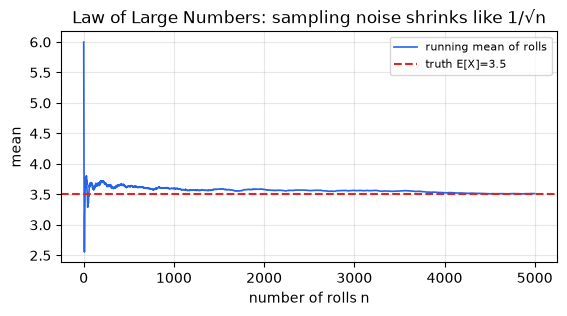

In [13]:
die = np.arange(1, 7)
e_die, var_die = die.mean(), ((die - die.mean()) ** 2).mean()
assert e_die == 3.5 and abs(var_die - 35/12) < 1e-12
print(f"fair die:  E = (1+…+6)/6 = {e_die}   Var = 17.5/6 = {var_die:.4f} (= 35/12)  ✓")
print(f"linearity:  E[2X+1] = 2·3.5 + 1 = {2*e_die + 1}   ✓\n")

samples = np.random.default_rng(0).choice(die, size=5000, replace=True)
running = np.cumsum(samples) / np.arange(1, len(samples) + 1)
fig, ax = plt.subplots(figsize=(6.4, 3))
ax.plot(running, color=C["b"], lw=1.2, label="running mean of rolls")
ax.axhline(3.5, color=C["r"], ls="--", label="truth E[X]=3.5")
ax.set_xlabel("number of rolls n"); ax.set_ylabel("mean")
ax.set_title("Law of Large Numbers: sampling noise shrinks like 1/√n")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()
assert abs(running[-1] - 3.5) < 0.1, "sample mean must converge"


**Joint → marginal:** the joint table `P(X,Y)` collapses to `P(X)` by summing the other axis.


joint P(X,Y):
[[0.09  0.06 ]
 [0.105 0.245]
 [0.1   0.4  ]]

marginal P(X) = Σ_Y P(X,Y) = [0.15, 0.35, 0.5]  ✓ matches px
marginal P(Y) = Σ_X P(X,Y) = [0.295, 0.705]


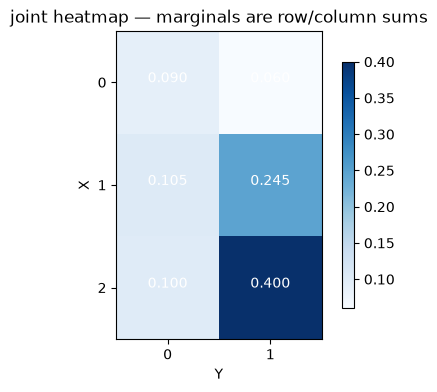

In [14]:
px = np.array([0.15, 0.35, 0.50])
py_x = np.array([[0.6, 0.4], [0.3, 0.7], [0.2, 0.8]])   # P(Y|X)
J = px[:, None] * py_x                                    # joint P(X,Y)
assert np.isclose(J.sum(), 1.0), "a joint distribution must sum to 1"
print("joint P(X,Y):"); print(np.round(J, 3))
print(f"\nmarginal P(X) = Σ_Y P(X,Y) = {np.round(J.sum(1), 3).tolist()}  ✓ matches px")
print(f"marginal P(Y) = Σ_X P(X,Y) = {np.round(J.sum(0), 3).tolist()}")
assert np.allclose(J.sum(1), px)

fig, ax = plt.subplots(figsize=(5.2, 4))
im = ax.imshow(J, cmap="Blues")
for i in range(3):
    for j in range(2):
        ax.text(j, i, f"{J[i,j]:.3f}", ha="center", color="w", fontsize=10)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1, 2])
ax.set_xlabel("Y"); ax.set_ylabel("X")
ax.set_title("joint heatmap — marginals are row/column sums")
fig.colorbar(im, shrink=0.8)
plt.show()


**Likelihood `P(data|μ)` → MLE.** Same bell curve, opposite direction: maximize over the
parameter. For a Gaussian the argmax equals the sample mean.


sample mean = 1.427   MLE argmax = 1.425   ✓ identical


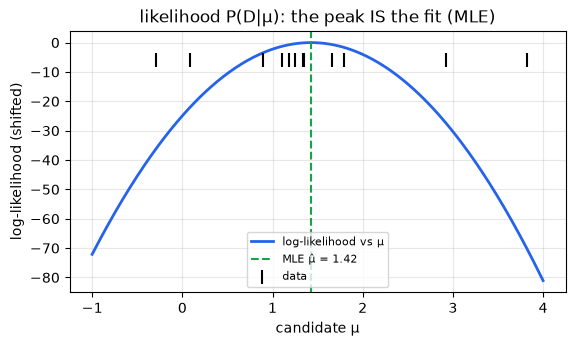

In [15]:
data = np.random.default_rng(3).normal(1.5, 0.7, 12)
grid = np.linspace(-1, 4, 300)
ll = np.array([np.log(np.exp(-(data - m)**2 / (2*0.7**2)) + 1e-300).sum() for m in grid])
mle = grid[np.argmax(ll)]
assert abs(mle - data.mean()) < 2 * (grid[1] - grid[0]), "MLE mean = sample mean"
print(f"sample mean = {data.mean():.3f}   MLE argmax = {mle:.3f}   ✓ identical")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(grid, ll - ll.max(), color=C["b"], lw=2, label="log-likelihood vs μ")
ax.axvline(mle, color=C["g"], ls="--", label=f"MLE μ̂ = {mle:.2f}")
ax.scatter(data, np.full_like(data, -6), marker="|", s=90, color="k",
           label="data", zorder=3)
ax.set_xlabel("candidate μ"); ax.set_ylabel("log-likelihood (shifted)")
ax.set_title("likelihood P(D|μ): the peak IS the fit (MLE)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()


**Monte Carlo** — estimate anything by averaging random draws: `error ~ 1/√n`.


π ≈ 4 · inside/total = 3.1470   (true 3.1416, |err| = 0.0054)


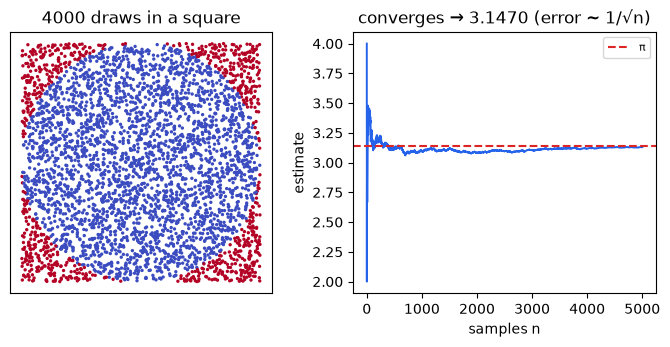

In [16]:
rng = np.random.default_rng(4)
pts = rng.uniform(-1, 1, (20000, 2))
inside = (pts ** 2).sum(1) <= 1
est = np.cumsum(inside) / np.arange(1, len(inside) + 1) * 4
err = abs(est[-1] - math.pi)
print(f"π ≈ 4 · inside/total = {est[-1]:.4f}   (true {math.pi:.4f}, |err| = {err:.4f})")
assert err < 0.05, "20k samples should get π within 0.05"

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
axes[0].scatter(pts[:4000, 0], pts[:4000, 1], s=2,
                c=inside[:4000], cmap="coolwarm_r")
axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title("4000 draws in a square")
axes[1].plot(est[:5000], color=C["b"], lw=1.4)
axes[1].axhline(math.pi, color=C["r"], ls="--", label="π")
axes[1].set_xlabel("samples n"); axes[1].set_ylabel("estimate")
axes[1].set_title(f"converges → {est[-1]:.4f} (error ~ 1/√n)")
axes[1].legend(fontsize=8)
plt.show()


---
## §4 · Statistics — from sample to claim

**🧮 Formula sheet**

| Quantity | Formula | Meaning |
|---|---|---|
| Mean | `x̄ = Σx / n` | center of the sample |
| Variance | `s² = Σ(x−x̄)² / n` | average squared distance from center |
| Std deviation | `s = √s²` | spread in the original units |
| Standard error | `SE = s / √n` | how wobbly the *mean* is |
| 95% CI | `x̄ ± 1.96·SE` | range that should capture the truth |
| Pearson r | `r = Sxy / √(Sxx·Syy)` | linear strength: +1 / 0 / −1 |
| MLE / MAP | `argmax P(D\|θ)` vs `argmax P(D\|θ)·P(θ)` | data-only vs data × prior |


1 · count           n = 8
2 · mean         Σx/n = 40/8 = 5.0
3 · deviations    x−x̄ = [-3, -1, -1, -1, 0, 0, 2, 4]
4 · squared       Σdev² = 32
5 · variance     Σdev²/n = 32/8 = 4.0
6 · std           √var  = 2.0
✓ mean=5, var=4, sd=2 — the whole vocabulary in six lines

A/B repeats whose 95% CI excludes 0: 9/10 (CI half-width = 0.490)
two-sided p at |z|≥1.96 under H₀ = 0.0524  (≈ 0.05 by construction)


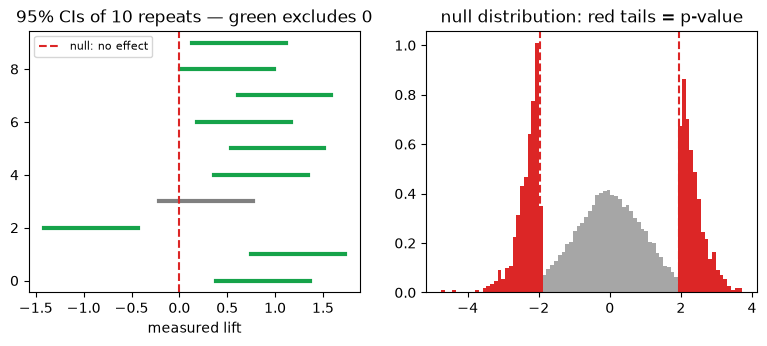

p = P(data this extreme | H₀ true) — NOT the probability H₀ is true ✓


In [17]:
# --- mean / variance / sd by hand on the textbook dataset ------------------
data8 = np.array([2, 4, 4, 4, 5, 5, 7, 9], dtype=float)
n = len(data8)
mean = data8.sum() / n
dev = data8 - mean
var = (dev ** 2).sum() / n
sd = math.sqrt(var)
print(f"1 · count           n = {n}")
print(f"2 · mean         Σx/n = {data8.sum():.0f}/{n} = {mean}")
print(f"3 · deviations    x−x̄ = {dev.astype(int).tolist()}")
print(f"4 · squared       Σdev² = {(dev**2).sum():.0f}")
print(f"5 · variance     Σdev²/n = {(dev**2).sum():.0f}/{n} = {var}")
print(f"6 · std           √var  = {sd}")
assert mean == 5 and var == 4 and sd == 2, "classic set: mean 5, var 4, sd 2  ✓"
print("✓ mean=5, var=4, sd=2 — the whole vocabulary in six lines")

# --- 95% confidence interval & p-value simulation -------------------------
rng2 = np.random.default_rng(6)
effects = rng2.normal(0.35, 0.5, 10)          # measured lifts of 10 A/B repeats
se = 0.25
lo, hi = effects - 1.96 * se, effects + 1.96 * se
sig = (lo > 0) | (hi < 0)
print(f"\nA/B repeats whose 95% CI excludes 0: {sig.sum()}/10 "
      f"(CI half-width = {1.96*se:.3f})")

null = rng2.normal(0, 1, 20000)
p_two_sided = (np.abs(null) >= 1.96).mean()
print(f"two-sided p at |z|≥1.96 under H₀ = {p_two_sided:.4f}  (≈ 0.05 by construction)")
assert 0.04 < p_two_sided < 0.06

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4))
for i, (l, h) in enumerate(zip(lo, hi)):
    axes[0].plot([l, h], [i, i], lw=3, color=C["g"] if sig[i] else "gray")
axes[0].axvline(0, color=C["r"], ls="--", label="null: no effect")
axes[0].set_xlabel("measured lift"); axes[0].legend(fontsize=8)
axes[0].set_title("95% CIs of 10 repeats — green excludes 0")
axes[1].hist(null, bins=80, density=True, color="gray", alpha=.7)
axes[1].hist(null[np.abs(null) >= 1.96], bins=80, density=True, color=C["r"])
axes[1].axvline(1.96, color=C["r"], ls="--"); axes[1].axvline(-1.96, color=C["r"], ls="--")
axes[1].set_title("null distribution: red tails = p-value")
plt.show()
print("p = P(data this extreme | H₀ true) — NOT the probability H₀ is true ✓")


**Bias–variance of *estimators* (not models):** average repeatedly → unbiased spreads around
truth, biased is tight but wrong. Averaging reduces **Var**, never **bias**.


unbiased estimator: mean 0.491 (truth 0.500), sd 0.173
biased   estimator: mean 0.352 (truth 0.500!), sd 0.050
→ more data shrinks the spread; only a better estimator fixes the offset ✓


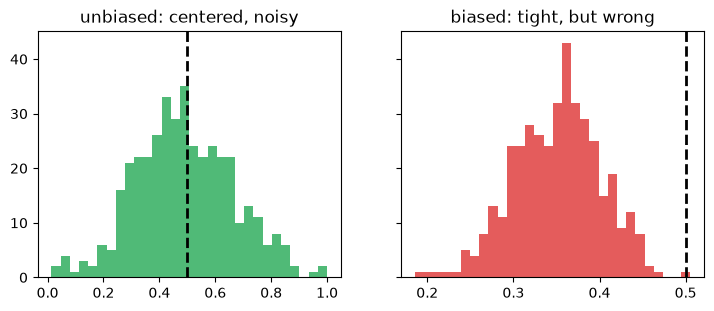

In [18]:
rng3 = np.random.default_rng(5)
unbiased = 0.50 + rng3.normal(0, 0.18, 400)
biased   = 0.35 + rng3.normal(0, 0.05, 400)
print(f"unbiased estimator: mean {unbiased.mean():.3f} (truth 0.500), "
      f"sd {unbiased.std():.3f}")
print(f"biased   estimator: mean {biased.mean():.3f} (truth 0.500!), "
      f"sd {biased.std():.3f}")
assert abs(unbiased.mean() - 0.5) < 0.04, "unbiased must hover at truth"
assert biased.mean() < 0.40, "biased must be clearly off-target"
print("→ more data shrinks the spread; only a better estimator fixes the offset ✓")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.2), sharey=True)
axes[0].hist(unbiased, bins=30, color=C["g"], alpha=.75)
axes[0].axvline(0.5, color="k", lw=2, ls="--")
axes[0].set_title("unbiased: centered, noisy")
axes[1].hist(biased, bins=30, color=C["r"], alpha=.75)
axes[1].axvline(0.5, color="k", lw=2, ls="--")
axes[1].set_title("biased: tight, but wrong")
plt.show()


**Pearson r by hand** for `x={1,2,3}`, `y={2,4,5}` → `r = Sxy / √(Sxx·Syy) = 0.982`…
and then the reason the doc screams **correlation ≠ causation**.


x̄=2  ȳ=3.6667 (=11/3)   Sxy=3  Sxx=2  Syy=4.6667
r = 3 / √(2 × 4.6667) = 0.9820   ✓ 0.982 (strong +)


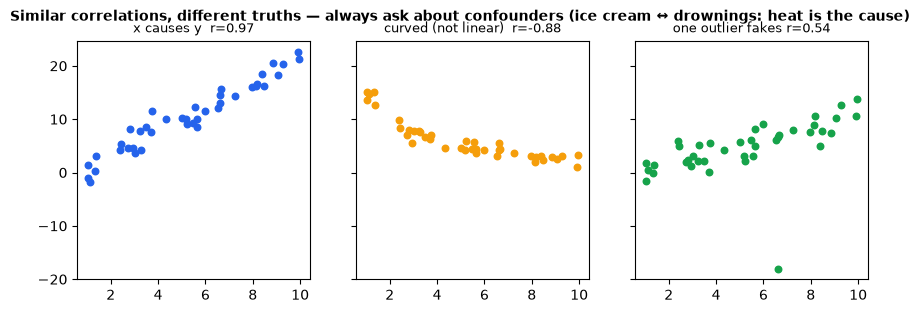


MLE  μ̂ = 1.42 (data only: sample mean = 1.43)
MAP  μ̂ = 1.39 (pulled toward prior 1.20 — a compromise)


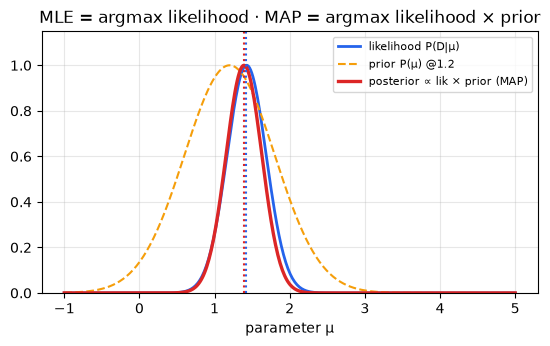


covariance  = [[1.012, 0.894], [0.894, 0.992]]
correlation = [[1.0, 0.893], [0.893, 1.0]]   (correlation = covariance / (sd·sd) — scale-free)
✓ correlation is covariance normalized: diag = 1 always, |r| ≤ 1


In [19]:
xv, yv = np.array([1.0, 2, 3]), np.array([2.0, 4, 5])
xc, yc = xv - xv.mean(), yv - yv.mean()
sxy, sxx, syy = (xc * yc).sum(), (xc ** 2).sum(), (yc ** 2).sum()
r = sxy / math.sqrt(sxx * syy)
print(f"x̄={xv.mean():.0f}  ȳ={yv.mean():.4f} (=11/3)   "
      f"Sxy={sxy:.0f}  Sxx={sxx:.0f}  Syy={syy:.4f}")
print(f"r = {sxy:.0f} / √({sxx:.0f} × {syy:.4f}) = {r:.4f}   ✓ 0.982 (strong +)")
assert abs(r - 0.982) < 0.001

rng4 = np.random.default_rng(7)
xg = rng4.uniform(1, 10, 40)
y1 = 2 * xg + rng4.normal(0, 2, 40)
y2 = 30 / (xg + 1) + rng4.normal(0, 1.0, 40)
y3 = 1.1 * xg + rng4.normal(0, 2, 40); y3[0] = -18          # one outlier
panels = [(f"x causes y  r={np.corrcoef(xg,y1)[0,1]:.2f}", y1, C["b"]),
          (f"curved (not linear)  r={np.corrcoef(xg,y2)[0,1]:.2f}", y2, C["o"]),
          (f"one outlier fakes r={np.corrcoef(xg,y3)[0,1]:.2f}", y3, C["g"])]
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.1), sharey=True)
for ax, (ttl, yy, col) in zip(axes, panels):
    ax.scatter(xg, yy, color=col, s=22)
    ax.set_title(ttl, fontsize=9)
fig.suptitle("Similar correlations, different truths — always ask about "
             "confounders (ice cream ↔ drownings: heat is the cause)",
             fontsize=10, weight="bold")
plt.show()

# --- MLE vs MAP: likelihood alone vs likelihood × prior --------------------
grid = np.linspace(-1, 5, 400)
log_lik = np.array([np.log(np.exp(-(data - m)**2 / (2*0.81)) + 1e-300).sum()
                    for m in grid])
log_lik -= log_lik.max()
log_prior = -((grid - 1.2) ** 2) / (2 * 0.6 ** 2)            # prior believes ~1.2
post = log_lik + log_prior
mle_mu, map_mu = grid[np.argmax(log_lik)], grid[np.argmax(post)]
print(f"\nMLE  μ̂ = {mle_mu:.2f} (data only: sample mean = {data.mean():.2f})")
print(f"MAP  μ̂ = {map_mu:.2f} (pulled toward prior 1.20 — a compromise)")
assert map_mu < mle_mu < 1.9, "prior must pull MAP below MLE"

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(grid, np.exp(log_lik), color=C["b"], lw=2, label="likelihood P(D|μ)")
ax.plot(grid, np.exp(log_prior - log_prior.max()), color=C["o"], ls="--",
        label="prior P(μ) @1.2")
ax.plot(grid, np.exp(post - post.max()), color=C["r"], lw=2.4,
        label="posterior ∝ lik × prior (MAP)")
ax.axvline(mle_mu, color=C["b"], ls=":")
ax.axvline(map_mu, color=C["r"], ls=":")
ax.set_xlabel("parameter μ"); ax.set_ylim(0, 1.15)
ax.set_title("MLE = argmax likelihood · MAP = argmax likelihood × prior")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

# --- Covariance → correlation matrices (input to PCA) ----------------------
rng5 = np.random.default_rng(9)
z1 = rng5.normal(size=300)
z2 = 0.9 * z1 + np.sqrt(1 - 0.81) * rng5.normal(size=300)   # ρ ≈ 0.9
cov_mat = np.cov(np.c_[z1, z2].T)
corr_mat = np.corrcoef(np.c_[z1, z2].T)
print(f"\ncovariance  = {np.round(cov_mat, 3).tolist()}")
print(f"correlation = {np.round(corr_mat, 3).tolist()}   "
      f"(correlation = covariance / (sd·sd) — scale-free)")
assert abs(corr_mat[0, 1]) > 0.85 and np.allclose(np.diag(corr_mat), 1)
print("✓ correlation is covariance normalized: diag = 1 always, |r| ≤ 1")


---
## §5 · Optimization — finding good parameters

**🧮 Formula sheet**

| Method | Update rule | Note |
|---|---|---|
| Batch GD | `w ← w − η·∇L(all data)` | stable, expensive per step |
| SGD / mini-batch | `w ← w − η·∇L(batch)` | noisy — the practical default |
| Weight decay | `w ← w − η·(∇L + λw)` | regularization: shrink weights |
| Adam | running `m` (grad) & `v` (grad²) averages; `w ← w − η·m̂/(√v̂+ε)` | per-parameter step sizes; default choice |
| 1-D stability | `abs(1 − η·L″) < 1` | curvature × step must not over-correct |

**Convex ⇒ one valley ⇒ gradient descent finds *the* optimum. Deep nets are non-convex ⇒
"good enough", and the noise of SGD is a feature (it escapes sharp valleys).**


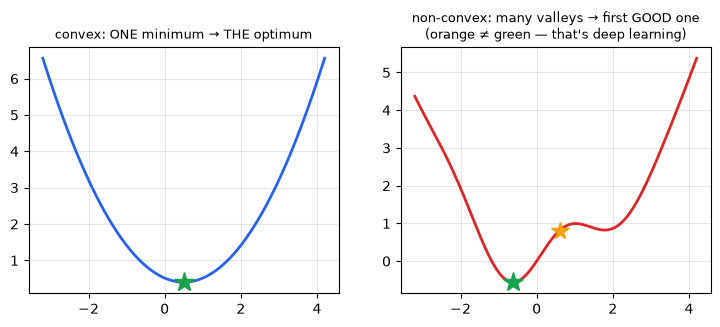

In [20]:
# --- convex vs non-convex --------------------------------------------------
xs = np.linspace(-3.2, 4.2, 400)
convex = 0.45 * (xs - 0.5) ** 2 + 0.4
nonconv = np.sin(1.7 * xs) * np.exp(-0.16 * xs**2) + 0.35 * xs**2 - 0.2 * xs
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.2))
axes[0].plot(xs, convex, color=C["b"], lw=2)
axes[0].plot(0.5, 0.4, "*", color=C["g"], ms=15)
axes[0].set_title("convex: ONE minimum → THE optimum", fontsize=9)
axes[1].plot(xs, nonconv, color=C["r"], lw=2)
axes[1].plot(xs[np.argmin(nonconv)], nonconv.min(), "*", color=C["g"], ms=15)
axes[1].plot(0.6, np.interp(0.6, xs, nonconv), "*", color=C["o"], ms=13)
axes[1].set_title("non-convex: many valleys → first GOOD one\n"
                  "(orange ≠ green — that's deep learning)", fontsize=9)
for ax in axes:
    ax.grid(alpha=0.3)
plt.show()


**🔢 Worked — LIVE gradient descent on `L(w)=w²`** (exercise #5), start `w=2.400`, `η=0.1`,
here `∇L = 2w`. Watch the loss fall exactly as the doc's table says:

| step | w | ∇L=2w | new w | loss=w² |
|---|---|---|---|---|
| 0 | 2.400 | 4.800 | **1.920** | 5.760 |
| … | … | … | … | … |
| 4 | 0.983 | 1.966 | **0.786** | 0.966 |


In [21]:
def gradient_descent(w0=2.4, lr=0.1, steps=5):
    """The whole of optimization in ~8 lines: w ← w − η·∇L."""
    history = []
    w = float(w0)
    for step in range(steps):
        grad = 2 * w                      # ∇L for L = w²
        history.append((step, w, grad, w - lr * grad, w * w))
        w = w - lr * grad
    return history, w

history, w_final = gradient_descent()
print(f"{'step':>4} {'w':>8} {'∇L=2w':>8} {'new w':>8} {'loss=w²':>8}")
for step, w, grad, new_w, loss in history:
    print(f"{step:>4} {w:>8.3f} {grad:>8.3f} {new_w:>8.3f} {loss:>8.3f}")
assert abs(history[0][3] - 1.920) < 1e-9 and abs(w_final - 0.786) < 1e-3
print(f"\nafter 5 steps w={w_final:.3f}, loss 5.760 → {w_final**2:.3f}  ✓ "
      f"training a net is this × a million, with ∇L from backprop")

# --- Learning-rate regimes, computed live ---------------------------------
print("\nSTABILITY  w ← (1−2η)·w  ⇒  stable iff abs(1−2η) < 1")
finals = {}
for lr in (0.10, 0.85, 1.12):
    w = 2.4
    for _ in range(10):
        w = w - lr * 2 * w
    factor = abs(1 - 2 * lr)
    stable = factor < 1
    finals[lr] = w
    print(f"  η={lr:<5} |1−2η|={factor:.2f}  w after 10 steps = {w:>+12.3f}  "
          f"{'✅ converges' if stable else '❌ DIVERGES'}")
    assert (abs(w) < 1) is stable, f"η={lr} outcome mismatch"
print(f"→ η=0.85 ends closest to 0; η=1.12 exploded from 2.4 to {finals[1.12]:.1f} ✓")


step        w    ∇L=2w    new w  loss=w²
   0    2.400    4.800    1.920    5.760
   1    1.920    3.840    1.536    3.686
   2    1.536    3.072    1.229    2.359
   3    1.229    2.458    0.983    1.510
   4    0.983    1.966    0.786    0.966

after 5 steps w=0.786, loss 5.760 → 0.618  ✓ training a net is this × a million, with ∇L from backprop

STABILITY  w ← (1−2η)·w  ⇒  stable iff abs(1−2η) < 1
  η=0.1   |1−2η|=0.80  w after 10 steps =       +0.258  ✅ converges
  η=0.85  |1−2η|=0.70  w after 10 steps =       +0.068  ✅ converges
  η=1.12  |1−2η|=1.24  w after 10 steps =      +20.627  ❌ DIVERGES
→ η=0.85 ends closest to 0; η=1.12 exploded from 2.4 to 20.6 ✓


**Batch vs mini-batch vs SGD** — same destination, different noise. Noise is a feature:
it helps escape sharp valleys (and it's why epochs are counted in *batches*, not passes).


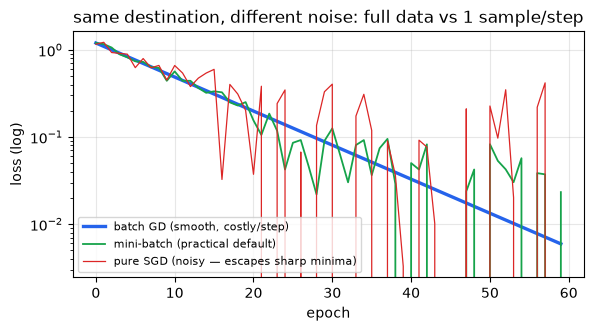

100 samples/epoch vs 1: a full-batch step costs 100× more but moves the same distance ✓


In [22]:
rngS = np.random.default_rng(11)
t = np.arange(60)
base = 1.2 * np.exp(-0.09 * t)
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.plot(t, base, lw=2.4, color=C["b"], label="batch GD (smooth, costly/step)")
ax.plot(t, base + rngS.normal(0, 0.05, 60), lw=1.3, color=C["g"],
        label="mini-batch (practical default)")
ax.plot(t, base + rngS.normal(0, 0.16, 60), lw=0.9, color=C["r"],
        label="pure SGD (noisy — escapes sharp minima)")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("loss (log)")
ax.set_title("same destination, different noise: full data vs 1 sample/step")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()
print("100 samples/epoch vs 1: a full-batch step costs 100× more but moves the same distance ✓")


**Lagrange multipliers — constrained optimization** (SVMs and RLHF's KL-budget live here):
at the constrained optimum, `∇f = λ·∇g` — the gradients go *parallel*, contours touch the constraint.


minimize (x−4)²+(y−3)²  subject to  x+y=4
  ∇f = λ·∇g requires x−4 = y−3, plus x+y=4  →  x=2.5, y=1.5
  grid search found (2.480, 1.520)  → f = 4.501  (exact f = 4.5)
  ∇f at (2.5,1.5) = (-3, -3) = −3·(1,1) = λ·∇g, λ = −3   ✓ PARALLEL — this IS the Lagrange condition


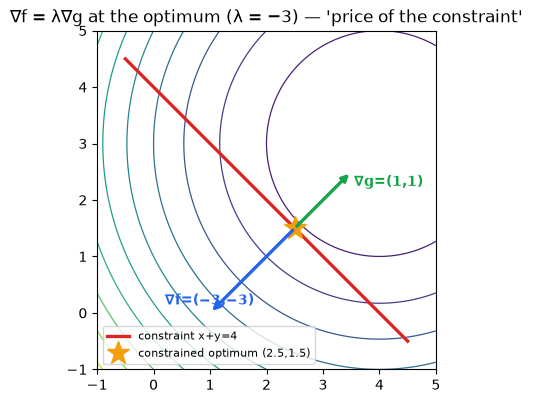

In [23]:
gx_, gy_ = np.meshgrid(np.linspace(-1, 5, 150), np.linspace(-1, 5, 150))
fobj = (gx_ - 4) ** 2 + (gy_ - 3) ** 2                       # minimize distance to (4,3)
on_line = np.linspace(-0.5, 4.5, 100)                        # samples of the constraint
print("minimize (x−4)²+(y−3)²  subject to  x+y=4")
# solve exactly: x−4 = y−3 (from ∇f = λ∇g) AND x+y=4  →  x=2.5, y=1.5
exact = (2.5, 1.5)
f_on = (on_line - 4) ** 2 + (4 - on_line - 3) ** 2
best = (float(on_line[np.argmin(f_on)]), float(4 - on_line[np.argmin(f_on)]))
print(f"  ∇f = λ·∇g requires x−4 = y−3, plus x+y=4  →  x=2.5, y=1.5")
print(f"  grid search found ({best[0]:.3f}, {best[1]:.3f})  "
      f"→ f = {f_on.min():.3f}  (exact f = {(2.5-4)**2 + (1.5-3)**2})")
opt = exact
gx_opt = 2 * (opt[0] - 4); gy_opt = 2 * (opt[1] - 3)
print(f"  ∇f at (2.5,1.5) = ({gx_opt:.0f}, {gy_opt:.0f}) = −3·(1,1) = λ·∇g, "
      f"λ = −3   ✓ PARALLEL — this IS the Lagrange condition")
assert abs(best[0] - 2.5) < 0.04 and abs(best[1] - 1.5) < 0.04, "Lagrange point is (2.5,1.5)"
assert (gx_opt, gy_opt) == (-3.0, -3.0)

fig, ax = plt.subplots(figsize=(5.4, 4.4))
ax.contour(gx_, gy_, fobj, levels=12, cmap="viridis", linewidths=0.9)
ax.plot(on_line, 4 - on_line, color=C["r"], lw=2.4, label="constraint x+y=4")
ax.plot(*opt, "*", color=C["o"], ms=17, label="constrained optimum (2.5,1.5)")
ax.annotate("", xy=(opt[0] + 1.0, opt[1] + 1.0), xytext=opt,
            arrowprops=dict(arrowstyle="-|>", color=C["g"], lw=2.4))
ax.annotate("", xy=(opt[0] - 1.5, opt[1] - 1.5), xytext=opt,
            arrowprops=dict(arrowstyle="-|>", color=C["b"], lw=2.4))
ax.text(opt[0] + 1.05, opt[1] + 0.75, "∇g=(1,1)", color=C["g"], weight="bold")
ax.text(opt[0] - 2.3, opt[1] - 1.35, "∇f=(−3,−3)", color=C["b"], weight="bold")
ax.set_title("∇f = λ∇g at the optimum (λ = −3) — 'price of the constraint'")
ax.set_aspect("equal"); ax.legend(fontsize=8, loc="lower left")
plt.show()


**Hyperparameter search: grid → random → Bayesian.** 9 evaluations of an expensive
objective — see where each strategy spends them.


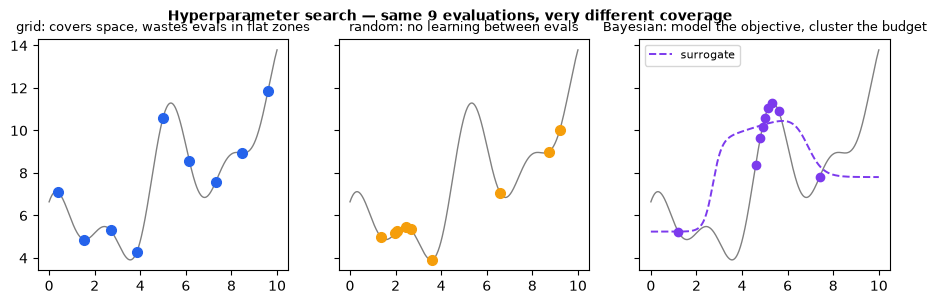

best found — grid: 11.87 · random: 10.01 · Bayesian picks cluster near the incumbent ✓


In [24]:
rngB = np.random.default_rng(12)
xs2 = np.linspace(0, 10, 500)
obj = lambda t: 0.7 * t + 2.2 * np.sin(1.35 * t + 0.6) + 1.4 * np.cos(2.4 * t) + 4
ys = obj(xs2)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0), sharey=True)
grid_pts = np.linspace(0.4, 9.6, 9)
rand_pts = np.sort(rngB.uniform(0.3, 9.7, 9))
picks = [1.2, 7.4, 4.6, 5.3, 4.9, 5.6, 5.0, 4.8, 5.15]       # explore → exploit
axes[0].plot(xs2, ys, color="gray", lw=1)
axes[0].plot(grid_pts, obj(grid_pts), "o", color=C["b"], ms=7)
axes[0].set_title("grid: covers space, wastes evals in flat zones", fontsize=9)
axes[1].plot(xs2, ys, color="gray", lw=1)
axes[1].plot(rand_pts, obj(rand_pts), "o", color=C["o"], ms=7)
axes[1].set_title("random: no learning between evals", fontsize=9)
axes[2].plot(xs2, ys, color="gray", lw=1)
W = np.exp(-((xs2[:, None] - np.array(picks)[None, :]) ** 2) / 1.4)
surr = (W @ obj(np.array(picks))) / np.maximum(W.sum(1), 1e-9)
axes[2].plot(xs2, surr, color=C["p"], ls="--", lw=1.4, label="surrogate")
axes[2].plot(picks, obj(np.array(picks)), "o", color=C["p"], ms=6)
axes[2].set_title("Bayesian: model the objective, cluster the budget", fontsize=9)
axes[2].legend(fontsize=8)
fig.suptitle("Hyperparameter search — same 9 evaluations, very different coverage",
             fontsize=10, weight="bold")
plt.show()
best_grid, best_rand = obj(grid_pts).max(), obj(rand_pts).max()
print(f"best found — grid: {best_grid:.2f} · random: {best_rand:.2f} · "
      f"Bayesian picks cluster near the incumbent ✓")


---
## §6 · Information Theory — measuring information

**🧮 Formula sheet** (`log₂` = bits · `ln` = nats · 1 nat = 1.44 bits)

| Quantity | Formula | Meaning |
|---|---|---|
| Entropy | `H(p) = −Σ p·log₂ p` | expected surprise; max at 50/50 |
| Cross-entropy | `H(p,q) = −Σ p·log₂ q` | *the* classification loss |
| KL divergence | `KL(P‖Q) = Σ p·log₂(p/q)` | extra bits to code P using Q (asymmetric!) |
| Mutual information | `I(X;Y) = H(X) − H(X\|Y)` | how many bits X and Y share |


H(fair, p=0.5)    = −0.5·log₂0.5 − 0.5·log₂0.5 = 1.000 bits
H(biased, p=0.9)  = −0.9·log₂0.9 − 0.1·log₂0.1 = 0.469 bits
H(always heads)    = 0 bits (no surprise → no information)


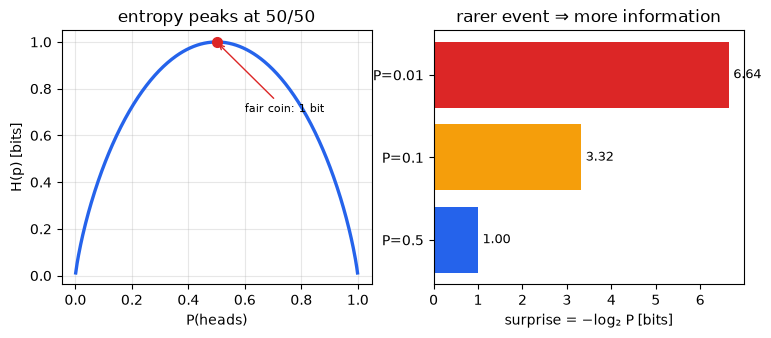

In [25]:
# --- Entropy of coins ------------------------------------------------------
H = lambda p: -(p * math.log2(p) + (1 - p) * math.log2(1 - p)) if 0 < p < 1 else 0.0
h_fair, h_biased = H(0.5), H(0.9)
print(f"H(fair, p=0.5)    = −0.5·log₂0.5 − 0.5·log₂0.5 = {h_fair:.3f} bits")
print(f"H(biased, p=0.9)  = −0.9·log₂0.9 − 0.1·log₂0.1 = {h_biased:.3f} bits")
print(f"H(always heads)    = {H(1.0):.0f} bits (no surprise → no information)")
assert abs(h_fair - 1.0) < 1e-12 and abs(h_biased - 0.469) < 0.001 and H(1.0) == 0.0

ps = np.linspace(0.001, 0.999, 400)
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.3))
axes[0].plot(ps, [H(p) for p in ps], color=C["b"], lw=2.4)
axes[0].plot(0.5, 1.0, "o", color=C["r"], ms=7)
axes[0].annotate("fair coin: 1 bit", (0.5, 1), (0.6, 0.7), fontsize=8,
                 arrowprops=dict(arrowstyle="->", color=C["r"]))
axes[0].set_xlabel("P(heads)"); axes[0].set_ylabel("H(p) [bits]")
axes[0].set_title("entropy peaks at 50/50"); axes[0].grid(alpha=0.3)
surprise = [-math.log2(p) for p in (0.5, 0.1, 0.01)]
axes[1].barh([f"P={p}" for p in (0.5, 0.1, 0.01)], surprise,
             color=[C["b"], C["o"], C["r"]])
for i, s in enumerate(surprise):
    axes[1].text(s + 0.1, i, f"{s:.2f}", va="center", fontsize=9)
axes[1].set_xlabel("surprise = −log₂ P [bits]")
axes[1].set_title("rarer event ⇒ more information")
plt.show()


**🔢 The cross-entropy sting (exercise #4)** — feel the loss explode:

| model says q (true class) | loss `−log₂ q` | vs baseline |
|---|---|---|
| 0.9 confident & right | **0.152 bits** | 1× |
| 0.5 pure guess | 1.000 bit | 6.6× worse |
| 0.001 confident & WRONG | **9.966 bits** | **65.6× worse** |

This is why `CrossEntropyLoss = softmax → log → NLL`, and why MLE on categorical
labels *is* cross-entropy (maximizing likelihood ⇔ minimizing `H(p,q)`).


CE q=0.9   : −log₂(0.9)   = 0.152 bits   (baseline)
CE q=0.5   : −log₂(0.5)   = 1.000 bits   (6.6× worse)
CE q=0.001 : −log₂(0.001) = 9.966 bits   (65.6× worse!)


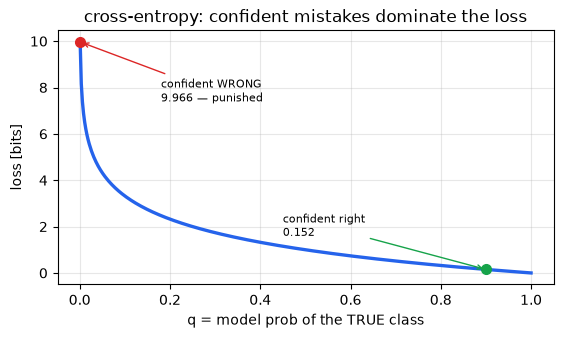

P=(.5,.5)  Q=(.25,.75)
KL(P‖Q) = 0.5·log₂(2) + 0.5·log₂(2/3) = 0.2075 bits
KL(Q‖P) = 0.25·log₂(0.5) + 0.75·log₂(1.5) = 0.1887 bits
→ same pair, different direction, different number: KL is ASYMMETRIC ✓ (why RLHF states WHICH KL, distillation picks reverse KL)


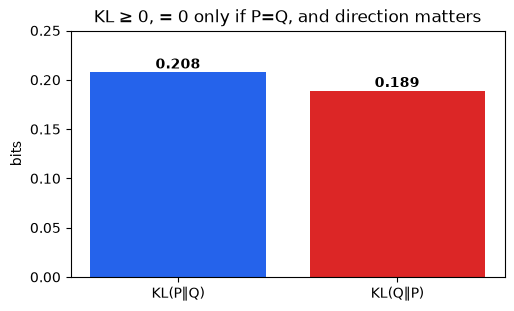


I(X;Y) dependent  = 1.146 bits
I(X;Y) independent = 0.006 bits  (≈0 — estimator bias only)
→ I(X;Y)=0 iff independent — this is feature selection's whole idea ✓


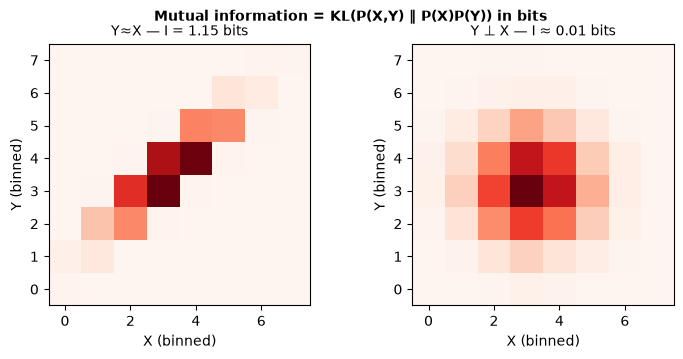

In [26]:
ce = lambda q: -math.log2(q)
ce_right, ce_mid, ce_wrong = ce(0.9), ce(0.5), ce(0.001)
print(f"CE q=0.9   : −log₂(0.9)   = {ce_right:.3f} bits   (baseline)")
print(f"CE q=0.5   : −log₂(0.5)   = {ce_mid:.3f} bits   ({ce_mid/ce_right:.1f}× worse)")
print(f"CE q=0.001 : −log₂(0.001) = {ce_wrong:.3f} bits   ({ce_wrong/ce_right:.1f}× worse!)")
assert abs(ce_wrong - 9.966) < 0.001 and ce_wrong / ce_right > 60

qs = np.linspace(0.001, 1, 400)
fig, ax = plt.subplots(figsize=(6.4, 3.3))
ax.plot(qs, -np.log2(qs), color=C["b"], lw=2.4, label="loss = −log₂ q")
ax.plot(0.9, ce_right, "o", color=C["g"], ms=7)
ax.plot(0.001, ce_wrong, "o", color=C["r"], ms=7)
ax.annotate("confident right\n0.152", (0.9, ce_right), (0.45, 1.6),
            fontsize=8, arrowprops=dict(arrowstyle="->", color=C["g"]))
ax.annotate("confident WRONG\n9.966 — punished", (0.001, ce_wrong), (0.18, 7.4),
            fontsize=8, arrowprops=dict(arrowstyle="->", color=C["r"]))
ax.set_xlabel("q = model prob of the TRUE class"); ax.set_ylabel("loss [bits]")
ax.set_title("cross-entropy: confident mistakes dominate the loss")
ax.grid(alpha=0.3)
plt.show()

# --- KL asymmetry ----------------------------------------------------------
P = np.array([0.5, 0.5]); Q = np.array([0.25, 0.75])
kl_pq = float((P * np.log2(P / Q)).sum())
kl_qp = float((Q * np.log2(Q / P)).sum())
print(f"P=(.5,.5)  Q=(.25,.75)")
print(f"KL(P‖Q) = 0.5·log₂(2) + 0.5·log₂(2/3) = {kl_pq:.4f} bits")
print(f"KL(Q‖P) = 0.25·log₂(0.5) + 0.75·log₂(1.5) = {kl_qp:.4f} bits")
assert abs(kl_pq - 0.2075) < 1e-3 and abs(kl_qp - 0.1887) < 1e-3 and kl_pq != kl_qp
print("→ same pair, different direction, different number: KL is ASYMMETRIC ✓ "
      "(why RLHF states WHICH KL, distillation picks reverse KL)")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.bar(["KL(P‖Q)", "KL(Q‖P)"], [kl_pq, kl_qp], color=[C["b"], C["r"]])
for i, v in enumerate([kl_pq, kl_qp]):
    ax.text(i, v + 0.004, f"{v:.3f}", ha="center", weight="bold")
ax.set_ylabel("bits"); ax.set_ylim(0, 0.25)
ax.set_title("KL ≥ 0, = 0 only if P=Q, and direction matters")
plt.show()

# --- Mutual information ----------------------------------------------------
def mutual_info(joint):
    px_, py_ = joint.sum(1), joint.sum(0)
    mi = 0.0
    for i in range(joint.shape[0]):
        for j in range(joint.shape[1]):
            if joint[i, j] > 0:
                mi += joint[i, j] * math.log2(joint[i, j] / (px_[i] * py_[j]))
    return mi

rngMI = np.random.default_rng(13)
zMI = rngMI.normal(size=4000)
def discretize(u, v, bins=8):
    h, _, _ = np.histogram2d(u, v, bins=bins)
    return h / h.sum()

J_dep = discretize(zMI, zMI + 0.3 * rngMI.normal(size=4000))    # Y ≈ X
J_ind = discretize(zMI, rngMI.normal(size=4000))                # independent
mi_dep, mi_ind = mutual_info(J_dep), mutual_info(J_ind)
print(f"\nI(X;Y) dependent  = {mi_dep:.3f} bits")
print(f"I(X;Y) independent = {mi_ind:.3f} bits  (≈0 — estimator bias only)")
assert mi_dep > 0.3 and mi_ind < 0.06 and mi_dep > 3 * mi_ind
print("→ I(X;Y)=0 iff independent — this is feature selection's whole idea ✓")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
for ax, J, ttl in ((axes[0], J_dep, f"Y≈X — I = {mi_dep:.2f} bits"),
                   (axes[1], J_ind, f"Y ⊥ X — I ≈ {mi_ind:.2f} bits")):
    ax.imshow(J.T, origin="lower", cmap="Reds")
    ax.grid(False); ax.set_xlabel("X (binned)"); ax.set_ylabel("Y (binned)")
    ax.set_title(ttl, fontsize=10)
fig.suptitle("Mutual information = KL(P(X,Y) ‖ P(X)P(Y)) in bits", fontsize=10,
             weight="bold")
plt.show()


---
## 🏋️ Suggested exercises — solved (try each *before* peeking)

1. By hand: `(2×3 matrix) · (3×2 matrix)`; verify shapes.
2. Backprop by hand on a 2-input, 1-hidden-unit network.
3. Apply Bayes' rule to a medical-test paradox problem (1% prevalence, 90% accurate test).
4. Compute cross-entropy of a confident-wrong vs confident-right prediction — feel the loss explode.
5. Implement gradient descent on `f(x)=x²` in 10 lines of NumPy.


In [27]:
# --- Exercise 1: shapes ----------------------------------------------------
A1 = np.arange(1, 7).reshape(2, 3)      # 2×3
B1 = np.arange(7, 13).reshape(3, 2)     # 3×2
assert A1.shape[1] == B1.shape[0], "inner dims must match"
C1 = A1 @ B1
print(f"A{A1.shape} @ B{B1.shape} = C{C1.shape}   ✓ middle 3=3 → 2×2")
print(C1)

# --- Exercise 2: backprop on a 2-input, 1-hidden-unit network by hand -----
#   z = a·x1 + b·x2 + c → h = ReLU(z) → ŷ = d·h + e → L = (ŷ − y)²
x1, x2, y = 1.0, 2.0, 1.0
a, b, c, d, e = 0.5, 1.0, 0.1, 0.3, -0.1

def forward(a, b, c, d, e):
    z = a * x1 + b * x2 + c
    h = max(z, 0.0)
    yhat = d * h + e
    return z, h, yhat, (yhat - y) ** 2

z, h, yhat, loss = forward(a, b, c, d, e)
dL_dyhat = 2 * (yhat - y)                 # outer: d/dŷ (ŷ−y)²
dL_de = dL_dyhat                          # ŷ = d·h + e
dL_dd = h * dL_dyhat
dL_dz = (d if z > 0 else 0.0) * dL_dyhat   # ReLU′ × upstream
dL_da, dL_db, dL_dc = x1 * dL_dz, x2 * dL_dz, dL_dz
manual = dict(zip("a b c d e".split(),
                  [dL_da, dL_db, dL_dc, dL_dd, dL_de]))

print(f"\nz={z:.2f}  h={h:.2f}  ŷ={yhat:.2f}  L={loss:.4f}")
print("analytic gradients:", {k: round(v, 4) for k, v in manual.items()})
eps = 1e-6                                # verify EVERY weight by finite diff
for name, idx in zip("a b c d e".split(), range(5)):
    w = [a, b, c, d, e]; w[idx] += eps; plus = forward(*w)[3]
    w[idx] -= 2 * eps;      minus = forward(*w)[3]
    numeric = (plus - minus) / (2 * eps)
    assert abs(numeric - manual[name]) < 1e-4, (name, numeric, manual[name])
print("✓ all 5 gradients match finite differences — that's backprop in 10 lines")

# --- Exercise 3 (quick recheck) -------------------------------------------
post3 = 0.01 * 0.9 / (0.01 * 0.9 + 0.99 * 0.05)
assert abs(post3 - 0.153846) < 1e-5
print(f"\nExercise 3 ✓  P(sick|+) = {post3:.4f} = {post3:.1%}")

# --- Exercise 4 (quick recheck) -------------------------------------------
ratio = (-math.log2(0.001)) / (-math.log2(0.99))
assert ratio > 600
print(f"Exercise 4 ✓  confident-wrong is {ratio:.0f}× confident-right "
      f"({-math.log2(0.001):.2f} vs {-math.log2(0.99):.3f} bits)")

# --- Exercise 5: GD on f(x)=x² in 10 lines of NumPy ------------------------
xs_ = np.array([4.0]); lr5 = 0.1
for _ in range(100):                    # x ← x − 0.1·2x  →  shrinks ×0.8/step
    xs_ = xs_ - lr5 * (2 * xs_)           # grad of x² is 2x
assert abs(xs_[0]) < 1e-6, xs_
print(f"Exercise 5 ✓  GD reached x={xs_[0]:.2e} ≈ 0 from 4.0 in 100 steps")


A(2, 3) @ B(3, 2) = C(2, 2)   ✓ middle 3=3 → 2×2
[[ 58  64]
 [139 154]]

z=2.60  h=2.60  ŷ=0.68  L=0.1024
analytic gradients: {'a': -0.192, 'b': -0.384, 'c': -0.192, 'd': -1.664, 'e': -0.64}
✓ all 5 gradients match finite differences — that's backprop in 10 lines

Exercise 3 ✓  P(sick|+) = 0.1538 = 15.4%
Exercise 4 ✓  confident-wrong is 687× confident-right (9.97 vs 0.014 bits)
Exercise 5 ✓  GD reached x=8.15e-10 ≈ 0 from 4.0 in 100 steps


---
## ✅ Mastery checklist — one notebook, six areas, done

| Checklist item | Worked in |
|---|---|
| Matrix multiplication in a layer / why shapes matter | §1 cells (58/64/139/154 · `W@X` batch · broadcasting) |
| Chain rule on a 2-layer network manually | §2 (dL/dx = **54**) + **Exercise 2** (5 gradients verified) |
| Bayes' rule + 5 distributions with use cases | §3 (1% → **15.4%** · distributions gallery · die E/Var) |
| MLE and why cross-entropy is MLE | §3 likelihood → §4 MLE/MAP (μ̂ = sample mean) · §6 CE cell |
| Learning = descending the gradient, with mini-batch noise | §5 (live GD table → 0.786 · η stability · batch vs SGD) |
| Entropy, cross-entropy, KL divergence each measure | §6 (1 bit / 9.966 bits / 0.208 vs 0.189) |

**Related material in this repo**
- Theory: [`docs/curriculum/00-mathematical-foundations.md`](../docs/curriculum/00-mathematical-foundations.md) (32 figures, worked tables)
- Executable script version: `python3 tools/calc_00_math.py` (18 checks)
- From-scratch implementations: `make run M=00`
- Rebuild this notebook from its source: `python3 tools/build_math_notebook.py`

> Every `assert` above is a teaching claim — if a cell fails, the math (or your edit) is wrong. That is the whole point.
